In [1]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv

In [2]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\nu_beta_effects'

In [3]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [4]:
os.chdir(Path(notebook_dir).parents[3])

In [5]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

In [6]:
import sys  
sys.path.insert(1,stvelo_path)
from pipelines.simulation_3ode_class import Simulation3ODE
from pipelines.metrics import *
from pipelines.preprocessing import Preprocessing
from pipelines.compute_velocity import Velocities
from pipelines.utils import proportions_nuc_cyto

In [7]:
import numpy as np

def compute_lognormal_params(means, std):
    """
    Computes the means and standard deviations of the log-transformed variables
    for a log-normal distribution, given desired means and coefficients of variation.

    Parameters:
    - means: list or array-like of desired mean values in the original scale.
    - cvs: list or array-like of coefficients of variation (CV = sigma_X / mu_X) for each variable.

    Returns:
    - means_ln: list of means of the log-transformed variables (mu_lnX).
    - stds_ln: list of standard deviations of the log-transformed variables (sigma_lnX).
    """
    # Ensure inputs are NumPy arrays
    means = np.array(means, dtype=np.float64)
    std = np.array(std,dtype=np.float64)
    cvs = std/means
    
    # cvs = np.array(cvs, dtype=np.float64)

    # Validate inputs
    if means.shape[0] != 4 or cvs.shape[0] != 4:
        raise ValueError("Means and CVs must be of length 4 (for alpha, beta, nu, gamma).")
    if np.any(means <= 0):
        raise ValueError("All mean values must be positive.")
    if np.any(cvs < 0):
        raise ValueError("All CVs must be non-negative.")

    # Compute sigma^2 = ln(1 + CV^2)
    sigma_sq = np.log(1 + cvs ** 2)

    # Compute sigma = sqrt(sigma^2)
    sigma_lnX = np.sqrt(sigma_sq)

    # Compute mu = ln(mean) - (sigma^2) / 2
    mu_lnX = np.log(means) - (sigma_sq / 2)

    return mu_lnX.tolist(), sigma_lnX.tolist()




In [8]:
means_original = [8,0.8,0.7,0.6]
# Coefficients of variation for each mean value
# For example: CV = standard deviation / mean
std = [2, 0.3, 0.2, 0.2]

In [69]:
means = np.array(means_original, dtype=np.float64)
std = np.array(std,dtype=np.float64)
cvs = std/means

In [70]:
cvs

array([0.25      , 0.375     , 0.28571429, 0.33333333])

In [9]:
# Desired mean values in original scale for alpha, beta, nu, gamma
# means_original = [6, 0.5, 0.44, 0.41]
means_original = [8,0.8,0.7,0.6]
# Coefficients of variation for each mean value
# For example: CV = standard deviation / mean
std = [2, 0.3, 0.2, 0.2]

# Compute the means and standard deviations of the log-transformed variables
means_ln, stds_ln = compute_lognormal_params(means_original, std)

# Output the results
print("Means of log-transformed variables (mu_lnX):", means_ln)
print("Standard deviations of log-transformed variables (sigma_lnX):", stds_ln)

Means of log-transformed variables (mu_lnX): [2.0491292307716185, -0.2889317302085693, -0.3959107516594801, -0.5635058815949039]
Standard deviations of log-transformed variables (sigma_lnX): [0.24622067706923975, 0.36273455554815737, 0.2801278555258211, 0.32459284597450133]


In [10]:
import numpy as np

def compute_log_transformed_correlations(sigma_lnX, rho_XY_list):
    """
    Computes the correlations between the log-transformed variables (ln X_i) given
    the standard deviations of the log-transformed variables and the correlations
    between the original variables (X_i).

    Parameters:
    - sigma_lnX: list of standard deviations of the log-transformed variables (sigma_lnX_i)
                 in the order [sigma_ln_alpha, sigma_ln_beta, sigma_ln_nu, sigma_ln_gamma]
    - rho_XY_list: list of correlations between the original variables, in the order
                   [rho_alpha_beta, rho_alpha_nu, rho_alpha_gamma,
                    rho_beta_nu, rho_beta_gamma, rho_nu_gamma]

    Returns:
    - rho_lnX_lnY_list: list of correlations between the log-transformed variables, in the same order
    """
    # Indices of pairs
    pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]

    # Convert sigma_lnX to numpy array
    sigma_lnX = np.array(sigma_lnX)
    sigma_lnX_sq = sigma_lnX ** 2

    # Precompute V_i = e^{sigma_lnX_i^2} - 1
    V = np.expm1(sigma_lnX_sq)  # V_i = e^{sigma_i^2} - 1

    # Initialize list for rho_lnX_lnY
    rho_lnX_lnY_list = []

    for idx, (i, j) in enumerate(pairs):
        sigma_i_sq = sigma_lnX_sq[i]
        sigma_j_sq = sigma_lnX_sq[j]
        sigma_i = sigma_lnX[i]
        sigma_j = sigma_lnX[j]
        V_i = V[i]
        V_j = V[j]

        rho_XY = rho_XY_list[idx]

        # Compute s_{ij} = ln(1 + rho_XY * sqrt(V_i * V_j))
        s_ij = np.log(1 + rho_XY * np.sqrt(V_i * V_j))

        # Compute rho_lnX_lnY = s_{ij} / (sigma_i * sigma_j)
        rho_lnX_lnY = s_ij / (sigma_i * sigma_j)

        # Append to list
        rho_lnX_lnY_list.append(rho_lnX_lnY)

    return rho_lnX_lnY_list



In [11]:
stds_ln

[0.24622067706923975,
 0.36273455554815737,
 0.2801278555258211,
 0.32459284597450133]

In [12]:
corra = [0.4, 0.3, -0.3, 0.2, -0.2, -0.3]

In [13]:
a = compute_log_transformed_correlations(sigma_lnX=stds_ln,rho_XY_list=corra)

In [15]:
a

[0.41219169719187254,
 0.30739745371896876,
 -0.31678356124861184,
 0.2086583922771492,
 -0.21502959048709364,
 -0.3187983564365868]

In [16]:
config_simulation_n = {'parameters':{ 'n_obs':3000,
    'n_vars':400,
    'alpha':None,
    'beta':None,
    'nu' :None,
    'gamma':None,
    'alpha_':0,
    't_max':40,
    'noise_model':"normal",
    'noise_level':2,
    }, 

    'options': {'generate_parameters':True,
                'generate_switch_times':True,
                  'save':False,
                  'saving_path':None
                  },
    'coeff_generate_options':{ 
    'corr':a,
    'sd':stds_ln,
    'mean':means_ln} }

In [ ]:
config_simulation_o = {'parameters':{ 'n_obs':1000,
    'n_vars':400,
    'alpha':None,
    'beta':None,
    'nu' :None,
    'gamma':None,
    'alpha_':0,
    't_max':30,
    'noise_model':"normal",
    'noise_level':2,
    }, 

    'options': {'generate_parameters':True,
                'generate_switch_times':True,
                  'save':False,
                  'saving_path':None
                  },
    'coeff_generate_options':{ 
    'corr':[0.1, 0.1, -0.1, 0.1, -0.1, -0.1],
    'sd':[0.6, 0.6, 0.6, 0.6],
    'mean':[np.log(5), np.log(0.02), np.log(0.34), np.log(0.33)]} }


In [250]:
# Order of correlations: [rho_alpha_beta, rho_alpha_nu, rho_alpha_gamma, rho_beta_nu, rho_beta_gamma, rho_nu_gamma]
# Order of sigmas : [sigma_log_alpha, sigma_log_beta, sigma_log_nu, sigma_log_gamma]
# Order of means : [alpha,beta,nu,gamma]

# config_simulation = {'parameters':{ 'n_obs':1000,
#     'n_vars':400,
#     'alpha':5,
#     'beta':0.02,
#     'nu' :0.33,
#     'gamma':0.32,
#     'alpha_':0,
#     't_max':30,
#     'noise_model':"normal",
#     'noise_level':2,
#     }, 

#     'options': {'generate_parameters':False,
#                 'generate_switch_times':True,
#                   'save':False,
#                   'saving_path':None
#                   },
#     }
config_simulation_o = {'parameters':{ 'n_obs':1000,
    'n_vars':400,
    'alpha':None,
    'beta':None,
    'nu' :None,
    'gamma':None,
    'alpha_':0,
    't_max':20,
    'noise_model':"normal",
    'noise_level':2,
    }, 

    'options': {'generate_parameters':True,
                'generate_switch_times':True,
                  'save':False,
                  'saving_path':None
                  },
    'coeff_generate_options':{ 
    'corr':[0.1, 0.1, -0.1, 0.1, -0.1, -0.1],
    'sd':[0.6, 0.6, 0.6, 0.6],
    'mean':[np.log(5), np.log(0.34), np.log(0.33), np.log(0.2)]} }

config_preprocessing = {'preprocess_params': {
     'min_counts': 200, 
     'min_cells': 5,
     'n_neighbors': 30,
     'n_pcs': None,
     'min_dist': 1,
     'resolution':1},
'functions_to_apply': {'filter_cells': True, 
                       'filter_genes': True, 
                       'normalize_total': True,
                       'log1p': True,
                       'pca': True,
                       'neighbors': True,
                       'umap': True,
                       'leiden': True,
                       'moments': True}}


# config_velocity = { 'velocity_types': ['dynamical','deterministic','stochastic','velovi']}
config_velocity = { 'velocity_types': ['deterministic','stochastic','dynamical','velovi'],
                   'velovi_model_params':{'n_hidden':256,
                                    'n_latent':10,
                                    'n_layers':1,
                                    },
                    'velovi_train_params': {'epochs':600,
                                            'lr':0.01,
                                            'weight_decay':0.01,
                                            'early_stop':True,
                                            'batch_size':256},
                     'velovi_getting_parameters':{'t_max' :30 ,
                                           'n_samples':25}}



config_plotting = {
    'colorsets': ['leiden', 'clusters'],
    'velocity_embedding_stream': True,
    'velocity_embedding_grid': True,
    'velocity_embedding': True,
    'rank_velocity_genes': True,
    'velocity_confidence': True,
    'velocity_length': True
}



# Simulation 

In [26]:
from pipelines.simulations_3ode_class_v1 import Simulation3ODE as Simulation3ODE_n

In [17]:
# simulator_o = Simulation3ODE(config= config_simulation_o) 
# adata_dict = simulator.simulate_multi_obs_var(n_obs_list=[1000], n_vars_list=[400])
# adata_dict = simulator_o.simulation()
simulator_n = Simulation3ODE(config= config_simulation_n)
adata_dict_n = simulator_n.simulation()

mean values of [alpha,beta,nu,gamma]:[2.0491292307716185, -0.2889317302085693, -0.3959107516594801, -0.5635058815949039]
parameters for 400 genes,  generated with the covariance matrix: [[ 0.06062462  0.03681397  0.02120221 -0.02531781]
 [ 0.03681397  0.13157636  0.02120221 -0.02531781]
 [ 0.02120221  0.02120221  0.07847162 -0.02898754]
 [-0.02531781 -0.02531781 -0.02898754  0.10536052]]
8.11852481826102
0.8185066479775217
0.6953761925066643
0.5901760036543188


In [24]:
config_simulation_n = {'parameters':{ 'n_obs':3000,
    'n_vars':400,
    'alpha':None,
    'beta':None,
    'nu' :None,
    'gamma':None,
    'alpha_':0,
    't_max':40,
    'noise_model':"normal",
    'noise_level':2,
    }, 

    'options': {'generate_parameters':True,
                'generate_switch_times':True,
                  'save':False,
                  'saving_path':None
                  },
    'coeff_generate_options':{ 
    'corr':[0.4, 0.3, -0.3, 0.2, -0.2, -0.3],
    'sd':[2,0.3,0.2,0.2],
    'mean':[8,0.8,0.7,0.6]} }

In [27]:
simulator_n = Simulation3ODE_n(config= config_simulation_n)
adata_dict_n = simulator_n.simulation()

mean values of [alpha,beta,nu,gamma]:[8, 0.8, 0.7, 0.6]
parameters for 400 genes,  generated with the covariance matrix: [[ 0.06062462  0.03681397  0.02120221 -0.02531781]
 [ 0.03681397  0.13157636  0.02120221 -0.02531781]
 [ 0.02120221  0.02120221  0.07847162 -0.02898754]
 [-0.02531781 -0.02531781 -0.02898754  0.10536052]]
7.945301657788732
0.7683500660439612
0.6998307873336063
0.5970953245503625


In [28]:
np.corrcoef(simulator_n.alpha,simulator_n.beta)

array([[1.       , 0.4035372],
       [0.4035372, 1.       ]])

In [31]:
np.std(simulator_n.beta)

0.25948078898686416

In [215]:
for k , adata in adata_dict_n.items():
    adata.X= adata.layers['unspliced']/adata.layers['unspliced']


In [126]:
adata_dict_n['adata_n_c_3000obs_400genes'].layers['unspliced'].shape

(3000, 400)

In [189]:
adata_dict_n['adata_n_c_3000obs_400genes']

AnnData object with n_obs × n_vars = 3000 × 400
    obs: 'true_t', 'n_counts', 'leiden'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'

In [55]:
import numpy as np

In [83]:
alpha_o = simulator_o.alpha
beta_o = simulator_o.beta

In [180]:
alpha_n = simulator_n.alpha
beta_n = simulator_n.beta

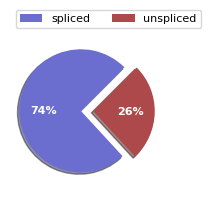

In [248]:
scv.pl.proportions(adata_dict_n['adata_s_u_3000obs_400genes'])

<Axes: >

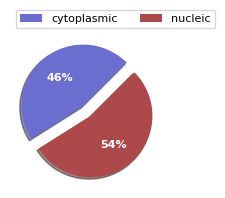

In [249]:
proportions_nuc_cyto(adata_dict_n['adata_n_c_3000obs_400genes'])

# Preprocessing 

In [240]:
for key, adata in adata_dict_n.items():
    print(f'{key} is being preprocessed.')
    preprocessor = Preprocessing(adata,config_preprocessing)
    adata = preprocessor.preprocess_data()

adata_s_u_3000obs_400genes is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
adata_n_c_3000obs_400genes is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [242]:
adata_dict_n['adata_n_c_3000obs_400genes']

AnnData object with n_obs × n_vars = 1939 × 400
    obs: 'true_t', 'n_counts', 'leiden'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'

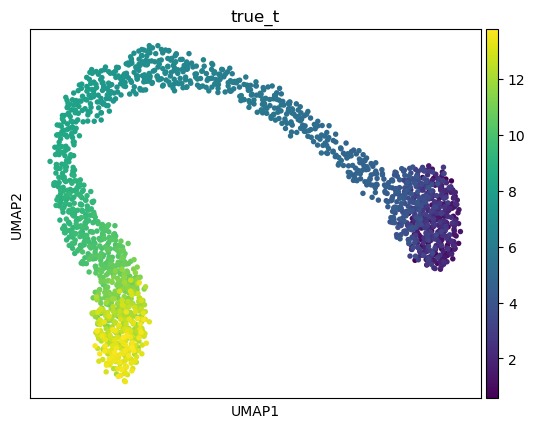

In [241]:
import scanpy as sc
sc.pl.umap(adata_dict_n['adata_s_u_3000obs_400genes'],color= 'true_t')

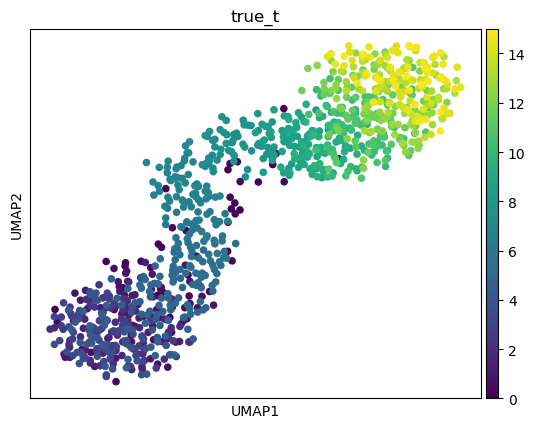

In [61]:
import scanpy as sc
sc.pl.umap(adata_dict_n['adata_s_u_1000obs_400genes'],color= 'true_t')

# Velocity 

In [16]:
velocity_computer = Velocities(adata_dict,config_velocity)

Using device: cuda


In [17]:
adata_dict_velocity = velocity_computer.compute_velocities()

deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:16) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
recovering dynamics (using 8/24 cores)
    finished (0:00:18) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
dynamical velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX A2000 8GB Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 154/600:  26%|██▌       | 154/600 [00:19<00:57,  7.78it/s, v_num=1, train_loss_step=8.16e+3, train_loss_epoch=7.99e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 8471.750. Signaling Trainer to stop.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
t_max:30
deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each in

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


    finished (0:00:18) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
Epoch 127/600:  21%|██        | 127/600 [00:12<00:47, 10.01it/s, v_num=1, train_loss_step=1.49e+4, train_loss_epoch=1.53e+4]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 14202.167. Signaling Trainer to stop.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
t_max:30


# Save adatas 

In [18]:
os.getcwd()

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github'

In [19]:
saving_path = os.path.join(os.getcwd(),'data','beta_small_2')

In [20]:
os.getcwd()

saving_path = os.path.join(os.getcwd(),'data','beta_small_2')
saving_path_vae = os.path.join(os.getcwd(),'data','vae')

vae = adata_dict_velocity[0]

np.save(os.path.join(saving_path_vae,'beta_small_2'), vae) 


adata_dict = adata_dict_velocity[1]

for d in adata_dict.keys():
    print(d)
    adata_dict[d].write(os.path.join(saving_path,d+'.h5ad'))

adata_s_u_1000obs_400genes_deterministic
adata_s_u_1000obs_400genes_stochastic
adata_s_u_1000obs_400genes_dynamical
adata_s_u_1000obs_400genes_velovi
adata_n_c_1000obs_400genes_deterministic
adata_n_c_1000obs_400genes_stochastic
adata_n_c_1000obs_400genes_dynamical
adata_n_c_1000obs_400genes_velovi


In [23]:
adata_dict = adata_dict_velocity[1]

In [24]:
for key, adata in adata_dict.items():
    true_beta = adata.var['true_beta']
    true_nu = adata.var['true_nu']
    true_gamma = adata.var['true_gamma']
    if 's_u' in key:
        true_ratio = (1/true_beta )* (1/((1/true_gamma)+(1/true_nu)))
    else:
        true_ratio = true_gamma*((1/true_nu)+(1/true_beta))
    adata.var['true_ratio'] = true_ratio

In [25]:
from scipy.stats import pearsonr

In [ ]:
a = adata_dict['adata_n_c_1000obs_400genes_deterministic'].var['true_ratio']
b = adata_dict['adata_n_c_1000obs_400genes_deterministic'].var['velocity_gamma']

In [72]:
read_dictionary = np.load('data/vae/beta_small_2.npy',allow_pickle='TRUE').item()
vae = read_dictionary['adata_n_c_1000obs_400genes_velovi']

In [73]:
a = adata_dict['adata_n_c_1000obs_400genes_velovi'].var['true_ratio']
b = adata_dict['adata_n_c_1000obs_400genes_velovi'].var['fit_gamma']/ adata_dict['adata_n_c_1000obs_400genes_velovi'].var['fit_beta']
c= vae.get_rates()["gamma"]/vae.get_rates()["beta"]

In [70]:
a

0       8.757527
1      11.555471
2      21.843635
3      15.766281
4      25.717385
         ...    
395    10.900884
396    33.162423
397    15.926322
398    28.045873
399    26.589988
Name: true_ratio, Length: 400, dtype: float64

In [69]:
c/scaling

array([ 1.3506424 ,  6.2034426 ,  6.646858  ,  1.6615998 ,  3.1023393 ,
        1.5505018 ,  1.6042831 ,  7.815809  ,  1.8227636 ,  2.3562815 ,
        2.6100311 ,  2.8852696 ,  1.049218  ,  0.83050925,  0.60307133,
        0.574465  ,  0.53041935,  0.87662315,  0.46278682,  2.819673  ,
        0.3672644 ,  5.3198986 ,  2.886416  ,  2.3490741 ,  1.4216298 ,
        1.6802278 ,  0.86987484,  1.7086257 ,  2.0308554 ,  0.90775615,
        1.0299139 ,  1.6387419 ,  1.597784  ,  1.2988735 ,  1.156986  ,
        0.7046834 ,  1.8480662 ,  0.8114322 ,  2.0527756 ,  1.60177   ,
        0.8543146 ,  1.5677502 ,  1.6736302 ,  0.5859512 ,  1.5373468 ,
       10.171917  ,  0.75532705,  0.69081026,  2.1725233 ,  1.185935  ,
        2.4182978 ,  1.6138747 ,  0.9347319 ,  1.827241  ,  1.2074299 ,
        1.9737855 ,  1.7036171 ,  1.1102885 ,  0.7286778 ,  1.8038391 ,
        2.061897  ,  0.51466626,  3.485164  ,  1.0803738 ,  1.5528457 ,
        1.9727286 ,  0.7967521 ,  0.62682885,  1.5580403 ,  0.89

In [76]:
cor = pearsonr(a,b)

In [77]:
cor[0]

0.14412185027750746

In [44]:
min(adata_dict['adata_n_c_1000obs_400genes_velovi'].var['true_t_'])

1.5953572372203986

In [58]:
latent_time = read_dictionary['adata_n_c_1000obs_400genes_velovi'].get_latent_time(n_samples=25)

In [67]:
scaling = 30 / latent_time.max(0)
scaling = np.array(scaling)

In [84]:
latent_time.max(0)

0       7.132499
1      11.336309
2       8.704609
3      11.554673
4       7.637457
         ...    
395     6.589297
396     7.493535
397     6.259007
398     6.914904
399    12.180807
Length: 400, dtype: float32